# <font color=green>LivingEarth PNG - FAO LCCS Level 3</font>

### An environmental layers testing framework for the FAO land cover classification system

The purpose of this notebook is to provide an easy-to-use method for testing environmental layers to use for classification and seeing how changes to particular layers effect the final Land Cover Classification. You can easily test with different environmental layer inputs, and different locations. 

This code defines 5 variables to contain the binary layers required to reach a level 3 classification:
1. <font color=blue>**vegetat_veg_cat:**</font> Vegetated / Non-Vegetated 
2. <font color=blue>**aquatic_wat_cat:**</font> Aquatic / Terrestrial 
3. <font color=blue>**cultman_agr_cat:**</font> Natural Vegetation / Crop or Managed Vegetation
4. <font color=blue>**artific_urb_cat:**</font> Natural Surfaces / Artificial Surfaces
5. <font color=blue>**artwatr_wat_cat:**</font> Natural Water / Artificial Water

Whilst this example is using open data cube to load the required data, it can be loaded from anywhere - so long as all input layers cover the same geographic region and are defined in a correctly labelled dataset, before being passed to the classification code.

#### Install the environment (need DEA fc and wofs packages) using the following on command line

In [1]:
'''
python3 -m venv ~/venvs/VP_Environment
source ~/venvs/VP_Environment/bin/activate
deactivate
realpath /env/lib/python3.10/site-packages > ~/venvs/VP_Environment/lib/python3.10/site-packages/base_venv.pth
source ~/venvs/VP_Environment/bin/activate
pip install --extra-index-url=https://packages.dea.ga.gov.au/ fc
pip install ephem
pip install --index-url https://packages.dea.ga.gov.au/ wofs
python -m ipykernel install --user --name=VP_Environment
cd venvs/VP_Environment
touch setup.py

##### add in text below to setup.py

from setuptools import setup, find_packages

setup(
    name='VP_Environment',
    version='1.0',
    packages=find_packages(),
    install_requires=[
        'ephem',
        'wofs',
        'fc'
    ],
)

#####

python setup.py bdist_egg

'''

"\npython3 -m venv ~/venvs/VP_Environment\nsource ~/venvs/VP_Environment/bin/activate\ndeactivate\nrealpath /env/lib/python3.10/site-packages > ~/venvs/VP_Environment/lib/python3.10/site-packages/base_venv.pth\nsource ~/venvs/VP_Environment/bin/activate\npip install --extra-index-url=https://packages.dea.ga.gov.au/ fc\npip install ephem\npip install --index-url https://packages.dea.ga.gov.au/ wofs\npython -m ipykernel install --user --name=VP_Environment\ncd venvs/VP_Environment\ntouch setup.py\n\n##### add in text below to setup.py\n\nfrom setuptools import setup, find_packages\n\nsetup(\n    name='VP_Environment',\n    version='1.0',\n    packages=find_packages(),\n    install_requires=[\n        'ephem',\n        'wofs',\n        'fc'\n    ],\n)\n\n#####\n\npython setup.py bdist_egg\n\n"

### **Import modules**

In [2]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import os, sys

import numpy as np
import xarray as xr
import geopandas as gpd
import rasterio
from rasterio.transform import from_bounds
import rioxarray
import datetime

from rasterio.enums import Resampling

from matplotlib import pyplot
import matplotlib.pyplot as plt

import datacube
from datacube.utils import masking
from datacube.utils.geometry import CRS
from dea_tools.plotting import display_map
from dea_tools.spatial import xr_rasterize
from datacube.testutils.io import rio_slurp_xarray

# For seagrass
from sentinel_processing import plot_s2_true_color_and_ssii
from tiff_map_overlay import overlay_tiff_on_map
from tiff_utils import main
from plot_ssii import plot_saved_ssii_tif


#import le_lccs modules
# sys.path.append("../livingearth_lccs")
from le_lccs.le_ingest import gridded_ingest
from le_lccs.le_classification import lccs_l3
from le_lccs.le_classification import lccs_l4

# for virtual products
from pathlib import Path
repo = Path.home() / 'livingearth_png/le_plugins'
sys.path.insert(1, str(repo))
import yaml
import importlib
from datacube.virtual import catalog_from_file
from datacube.virtual import DEFAULT_RESOLVER

# outputs
from datacube.utils.cog import write_cog
from datacube.drivers.netcdf import write_dataset_to_netcdf

dc = datacube.Datacube(app="level3")

# virtual product catalog
catalog = catalog_from_file('../le_plugins/virtual_product_cat.yaml')


### NEW

# Import colour schems for display
sys.path.append("../colourschemes/")
from colourschemes import vegetated_colours

sys.path.append("../functions/")
from myfunctions import plot_vegetated_areas
from myfunctions import export_to_geotiff

#### AWS Access

In [3]:
## Optional: Access AWS "requester-pays" buckets
# This is necessary for Landsat ("landsatN_c2l2_*") and Sentinel-2 ("s2_l2a") products
from datacube.utils.aws import configure_s3_access
configure_s3_access(aws_unsigned=False, requester_pays=True) ### add client=client here if launching a dask cluster

#### display AOI

In [9]:
# # Western Gulf mangrove area
#latitude = (-7.35, -7.4)
#longitude = (144.45, 144.5)

# # Port Moresby
#latitude = (-9.4, -9.5)
#longitude = (147.1, 147.2)

# # North Sri Lanka
#latitude = (9.08, 9.018)
#longitude = (80.02, 80.08)

# # East Sri Lanka
#latitude = (7.4777, 7.4023)
#longitude = (79.8260, 81.8382)
#display_map(longitude, latitude)

# # East Sri Lanka (small area)
#latitude = (9.60, 9.70)
#longitude = (79.95, 80.03)
#display_map(longitude, latitude)

# # # # # East Sri Lanka mangrove areas
# latitude = (9.1051, 8.9045)
# longitude = (79.8350, 80.0975)
# display_map(longitude, latitude)

# # # # East Sri Lanka mangrove areas (small)
latitude = (9.0973, 8.9945)
longitude = (80.03, 80.0975)
display_map(longitude, latitude)

# ## Timor Leste1
# latitude = (-8.4874, -8.5618)
# longitude = (126.1146, 126.2036)
# display_map(longitude, latitude)

# ## Timor Leste2
# latitude = (-8.4863, -8.5338)
# longitude = (125.7739, 125.8082)
# display_map(longitude, latitude)


# ## Fiji
# latitude = (-17.1037,-18.37)
# longitude = (-181, -183)
# display_map(longitude, latitude)



## <font color=blue>Set up query</font>

In [10]:
# THIS IS THE PREVIOUS VERSION AS BACKUP BUT DOES NOT GENERATE A GEOBOX BUT JUST A QUERY

time = ('2020-10-01', '2020-12-31')

# #Sri Lanka
crs = "EPSG:32644"
res = (10, -10)

# #Timor Leste
# crs = "EPSG:32751"
# res = (30, -30)

# # #Fiji
# crs = "EPSG:3141"
# res = (30, -30)

query =({'time': time,
            'latitude':latitude,
            'longitude':longitude,
            'output_crs':crs,
            'resolution':res})

## <font color=blue>Create environmental layers</font>

### 1. Vegetated / Non-Vegetated

#### **Primarily Vegetated Areas**:
   
**Available data:** 

**Mangroves:**  The GMW dataset is increasingly being regarded as the most up-to-date and is often used for area statistics.  Hence, for 2020, the extent of mangroves is taken from the GMW 10 m layer, generated as a contribution to the European Space Agency's (ES) World Cover product and indexed into EASI-ASIA. The GMW vector data for 2020 is located in the "data" directory.  GMW layers for other years can also be accessed remotely (see Mangrove_change_analysis notebook). 

**Saltmarshes:** Worthington et al. (2023) applied a random forest classification model to Earth observation data acquired in 2020 to map saltmarsh extent globally.  The classification model was trained with a reference dataset developed to support distribution mapping of coastal ecosystems and used to predict the spatial distribution of tidal marshes between 60°N to 60°S. Validation was achieved using standard accuracy assessment methods, with an overall accuracy score of 0.852 obtained. 

**Tidal probability:** The tidal marsh probability layer (Murray et al 2022) can be used, with the probability threshold set to > 50%.

**Fractional cover:** Allows differentiation between primarily vegetated (defined as supporting a vegetative cover for at least 4 % for at least two months of the year) and non-vegetated surfaces was achieved using Landsat-derived fractional cover, specifically the 90th annual percentile for both photosynthetic (PV) and non-photosynthetic vegetation (NPV). To be classified as a primarily vegetated pixel, the 90th annual percentile of PV fraction needed to be greater than 25%.  For wet tropical climates with evergreen tropical vegetation (e.g., PNG but many parts of Southeast Asia and especially on the coast, a further criterion was that only pixels with a 90th annual percentile of NPV fraction greater than 25% are classified as non-vegetated in order to distinguish between NPV and bare surfaces.

*(NB: This criteria differs from the DEA inplementation for Australia where areas have a vegetative cover of at least 4% for at least two months of the year, with these consisting of Woody (Trees, Shrubs) and/or Herbaceous (Forbs, Graminoids) lifeforms, or at least 25% cover of Lichens/Mosses when other life forms are absent).* 


This class applies to areas that have a 
      
**Primarily Non-Vegetated Areas**:
   Areas which are not primarily vegetated.
 

Fractional cover (FC) is used to distinguish between vegetated and not vegetated. 
http://data.auscover.org.au/xwiki/bin/view/Product+pages/Landsat+Fractional+Cover
<br>We are using the 90th annual percentile for both Photosyntheic (PV) and Non-photosynthetic (NPV) vegetation. This removes noise and outliers and gives a robust maximum annual value. A threshold is then applied where PV or NPV is greater than 50%, the rationale being that if a pixel is greater than 50% PV or NPV we can be confident that it is likely to be vegetated. In addition, a maximum threshold value is given to NPV as non-photosynthetic vegetation and bare soil (BS) fractions can be unreliable at maximum values due to inherent issues with unmixing NPV and BS signatures.

<font color=red>**TODO:**</font> need to calculate number of observations for annual time series to define vegetation correctly as in FAO guidelines. This will likely be similar to WOfS wet/clear obervations but for FC where PV or NPV is greater than 50% for 60 days per year

### Load the Global Mangrove Watch (GMW) layers
The Global Mangrove Watch (GMW) layer for a selected year (e.g., 2020) is read to include in the vegetation mask.

The layer is read in either a) as a shapefile (for all years before and including 2021) and rasterised to 30 m or b) as a raster from the World Cover 10 m dataset.



In [11]:
ESA_WorldCover = dc.load(
    product = 'esa_worldcover_2020',
    **query,
)
ESA_WorldCover

<xarray.Dataset>
Dimensions:         (time: 1, y: 1140, x: 746)
Coordinates:
  * time            (time) datetime64[ns] 2020-07-01T23:59:59.500000
  * y               (y) float64 9.944e+05 9.944e+05 ... 1.006e+06 1.006e+06
  * x               (x) float64 4.008e+05 4.008e+05 ... 3.934e+05 3.934e+05
    spatial_ref     int32 32644
Data variables:
    classification  (time, y, x) uint8 30 30 30 30 30 10 ... 80 80 80 80 80 80
Attributes:
    crs:           EPSG:32644
    grid_mapping:  spatial_ref

In [12]:
gmw_2020 = ESA_WorldCover.classification == 95

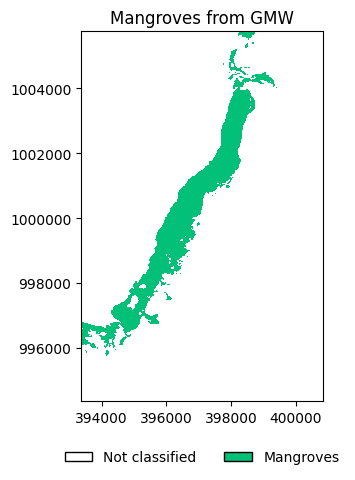

In [13]:
from myfunctions import plot_areas
from colourschemes import mangrove_colours, mangrove_labels
#from myfunctions import plot_areas
plot_areas(
    gmw_2020,          # Your dataset
    mangrove_colours,           # Color scheme
    mangrove_labels,            # Labels for the color scheme
    title="Mangroves from GMW",  # Optional custom title
    output_file="../figures/vegetated_mangrove.png"  # Optional output file path
)

In [14]:
# Define the output file path if want to export as a GeoTIFF
gmw_2020_tif = "gmw_2020_classification.tif"

# Export the gmw_2020 dataset (which is a DataArray) to a GeoTIFF
export_to_geotiff(gmw_2020, gmw_2020_tif)

GeoTIFF saved to: gmw_2020_classification.tif


### Load Intertidal Saltmarsh Extents (Worthington et al., 2023)


In [15]:
Tidal_Marsh = dc.load(
    product = 'global_tidal_marshes_2020',
    **query
)
Tidal_Marsh

<xarray.Dataset>
Dimensions:  ()
Data variables:
    *empty*

In [16]:
Tidal_Marsh_2020 = Tidal_Marsh

In [17]:
# Open Worthingtons's tidal wetland probability (2017-2019) file as xarray
saltmarsh_worthington_2020 = '/home/jovyan/data/tidal_marsh_80E_0N_v2_6.tif'
saltmarsh_2020 = rio_slurp_xarray(saltmarsh_worthington_2020, gbox=gmw_2020.geobox)

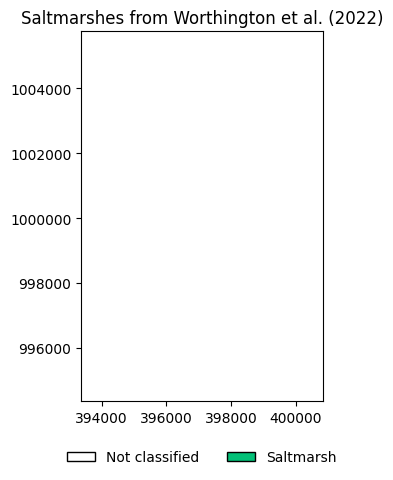

In [18]:
from colourschemes import saltmarsh_colours, saltmarsh_labels
plot_areas(
    saltmarsh_2020,          # Your dataset
    saltmarsh_colours,           # Color scheme
    saltmarsh_labels,            # Labels for the color scheme
    title="Saltmarshes from Worthington et al. (2022)",  # Optional custom title
    output_file="../figures/vegetated_saltmarsh.png"  # Optional output file path
)

In [19]:
# # Define the output file path if want to export as a GeoTIFF
# saltmarsh_2020_tif = "saltmarsh_2020_classification.tif"

# # Export the gmw_2020 dataset (which is a DataArray) to a GeoTIFF
# export_to_geotiff(saltmarsh_2020, saltmarsh_2020_tif)

### Load Cultivated Area Datasets
The cultivated area currently is determined from the World Cover map for Sri Lanka, noting that other datasets or algorithms can be ingested as a replacement. 

In [20]:
cultivated_2020 = ESA_WorldCover.classification == 40

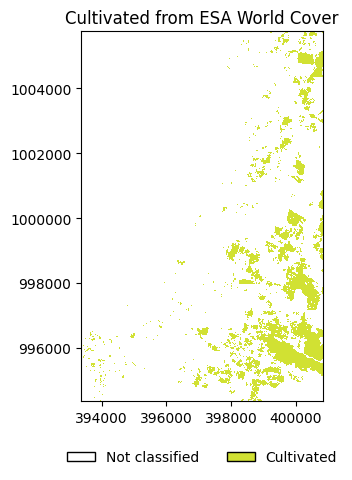

In [21]:
from colourschemes import cultivated_colours, cultivated_labels
plot_areas(
    cultivated_2020,          # Your dataset
    cultivated_colours,           # Color scheme
    cultivated_labels,            # Labels for the color scheme
    title="Cultivated from ESA World Cover",  # Optional custom title
    output_file="../figures/vegetated_cultivated.png"  # Optional output file path
)

In [22]:
# Define the output file path if want to export as a GeoTIFF
cultivated_2020_tif = "cultivated_2020_classification.tif"

# Export the gmw_2020 dataset (which is a DataArray) to a GeoTIFF
export_to_geotiff(cultivated_2020, cultivated_2020_tif)

GeoTIFF saved to: cultivated_2020_classification.tif


### Load Fractional cover datasets
The fractional cover data are used to establish the extent of vegetation that is outside of the area already mapped as mangrove by the GMW.  


In [23]:
# Load Fractional Cover

# Need to add any tranformations for the VP you're using
# Get location of transformation
transformation = "fractional_cover"
trans_loc = importlib.import_module(transformation)
trans_class = transformation.split('.')[-1]

DEFAULT_RESOLVER.register('transform', trans_class, getattr(trans_loc, trans_class) )

In [24]:
product = catalog['fractional_cover']
fractional_cover = product.load(dc, **query)
fractional_cover = masking.mask_invalid_data(fractional_cover)

In [25]:
# Load WOfS

# Need to add any tranformations for the VP you're using
# Get location of transformation
transformation = "WOfS"
trans_loc = importlib.import_module(transformation)
trans_class = transformation.split('.')[-1]

DEFAULT_RESOLVER.register('transform', trans_class, getattr(trans_loc, trans_class) )

In [26]:
product = catalog['WOfS']
wofs = product.load(dc, **query)
wofs = masking.mask_invalid_data(wofs)

wofs_mask = wofs["frequency"] >= 0.2

In [27]:
# Create binary layer representing vegetated (1) and non-vegetated (0)
#vegetat = ((fractional_cover["PV_PC_90"] >= 50) | ((fractional_cover["NPV_PC_90"] >= 50) & (fractional_cover["NPV_PC_90"] <= 80)))
vegetat = ((fractional_cover["PV_PC_90"] >= 30) | ((fractional_cover["NPV_PC_90"] >= 30) & (fractional_cover["NPV_PC_90"] <= 80)))

# mask out water here
vegetat = vegetat.where(wofs_mask == 0, 0, 1)

# Convert to Dataset and add name
vegetat_veg_cat_ds = vegetat.to_dataset(name="vegetat_veg_cat")#.squeeze().drop('time')

In [28]:
# Check the CRS of the vegetat layer
if hasattr(vegetat, 'geobox') and vegetat.geobox is not None:
    crs = vegetat.geobox.crs
    print("CRS of vegetat layer:", crs)
else:
    print("No CRS information found for vegetat layer.")

CRS of vegetat layer: PROJCS["WGS 84 / UTM zone 44N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",81],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32644"]]


In [29]:
# Check the CRS in the 'attrs' attribute
crs_from_attrs = vegetat.attrs.get('crs', 'No CRS found')
print("CRS from attrs:", crs_from_attrs)

CRS from attrs: No CRS found


In [30]:
import rasterio
from rasterio.enums import Resampling
import numpy as np

def export_to_geotiff_with_crs(dataset, output_path, crs):
    """
    Exports an xarray DataArray or numpy array to a GeoTIFF with correct CRS.

    Parameters:
    - dataset: The dataset (either xarray DataArray or numpy array) to export
    - output_path: Path to save the GeoTIFF file
    - crs: The CRS to embed in the GeoTIFF (as an EPSG code or CRS object)
    """

    # If the dataset is an xarray.DataArray, get the values as a numpy array
    if hasattr(dataset, 'values'):
        data_array = dataset.values
    else:
        # If it's already a numpy array, use it directly
        data_array = dataset

    # Check if dataset has a proper transform (geo-referencing information)
    try:
        transform = dataset.rio.transform()
    except AttributeError:
        raise ValueError("Dataset does not have geo-referencing transform information.")
    
    # Get dimensions (height and width)
    height, width = data_array.shape

    # Open the GeoTIFF file for writing
    with rasterio.open(
        output_path, 
        'w', 
        driver='GTiff', 
        count=1,  # Single band
        dtype=data_array.dtype,  # Ensure the correct dtype is used
        crs=crs,  # CRS (e.g., 'EPSG:32644')
        transform=transform,  # Transformation matrix (georeferencing)
        width=width, 
        height=height
    ) as dst:
        dst.write(data_array, 1)  # Write data to the first band

    print(f"GeoTIFF saved to: {output_path}")


# Example usage:
vegetat_tif = "vegetat_veg_cat_with_crs.tif"
output_crs = 'EPSG:32644'  # Example: UTM Zone 44N

# Assuming vegetat is the DataArray you want to export
export_to_geotiff_with_crs(vegetat, vegetat_tif, output_crs)

GeoTIFF saved to: vegetat_veg_cat_with_crs.tif


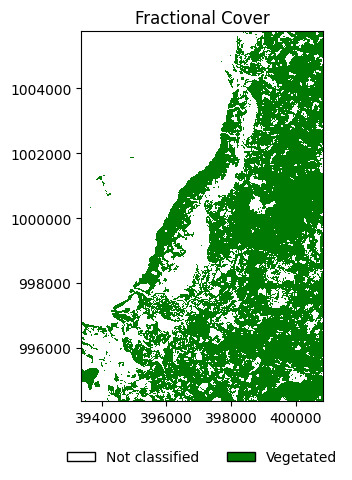

In [31]:
from colourschemes import vegetated_colours, vegetated_labels
#def plot_areas(input, colours, labels, title, output_file):
plot_areas(vegetat_veg_cat_ds.vegetat_veg_cat,vegetated_colours, vegetated_labels, title="Fractional Cover", output_file="../figures/fractional_output.png")

## Create binary mask of vegetated/not-vegetated

**Methods:** Three approaches can be implemented to identify vegetated landscapes and separate those that are non-vegetated.  

**A. Collation of all vegetation masks:** Collation of areas of vegetation are defined with reference to the extents of a) mangrove from the Global Mangrove Watch (GMW), b) tidal saltmarsh defined by Worthington et al. (2020) OR the tidal marsh probability layer of Murray et al. (2018) and c) vegetation mapped from fractional cover data.

**B. GMW and fractional cover:** a) The GMW mangrove extent is used first, followed by b) fractional cover. The saltmarsh extent layer (Worthington et al., 2023) OR tidal probability layer of Murray et al. (2018) are used to differentiate terrestrial from aquatic vegetation but in Level 2 of the FAO LCCS. 

**C. Fractional cover only:** Areas of vegetation are defined using the fractional cover layer only, noting that this can result in exclusion of some mangroves and/or saltmarshes. 


### Method A
Combine the binary maps of mangroves (GMW), saltmarsh (Worthington et al., 2023) and other vegetation (retrieved from the Landsat archive within EASI-ASIA).

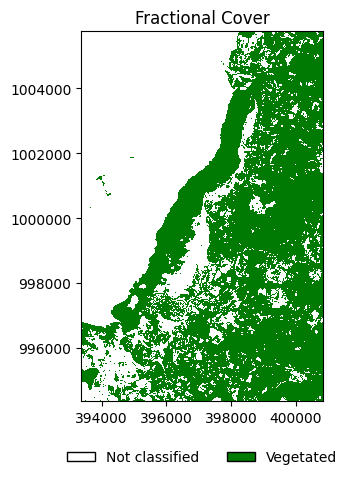

In [32]:
# Create binary layer representing vegetated (1) and non-vegetated (0)

# For coastal landscapes use the following
vegetat_veg_cat = (gmw_2020 | saltmarsh_2020 | vegetat | cultivated_2020)

# Convert to Dataset and add name
vegetat_veg_cat_ds = vegetat_veg_cat.to_dataset(name="vegetat_veg_cat").squeeze().drop('time')     

from colourschemes import vegetated_colours, vegetated_labels
#def plot_areas(input, colours, labels, title, output_file):
plot_areas(vegetat_veg_cat_ds.vegetat_veg_cat,vegetated_colours, vegetated_labels, title="Fractional Cover", output_file="../figures/vegetated_output.png")

In [33]:
# Define the output file path if want to export as a GeoTIFF
all_tif = "all_2020_classification.tif"

# Export the gmw_2020 dataset (which is a DataArray) to a GeoTIFF
export_to_geotiff(vegetat_veg_cat_ds.vegetat_veg_cat, all_tif)

GeoTIFF saved to: all_2020_classification.tif


### Method B: 
GMW and fractional cover:** a) The GMW mangrove extent is used followed by b) fractional cover. The tidal probability layer of Murray et al. (2018) is used to differentiate terrestrial from aquatic vegetation in Level 2 of the FAO LCCS. 

In [34]:
# Create binary layer representing vegetated (1) and non-vegetated (0)

# For coastal landscapes use the following
#vegetat_veg_cat = (gmw_2020 | vegetat)

# Convert to Dataset and add name
#vegetat_veg_cat_ds = vegetat_veg_cat.to_dataset(name="vegetat_veg_cat").squeeze().drop('time') 

# Plot output
# from colourschemes import vegetated_colours, vegetated_labels
# from myfunctions import plot_areas
# #def plot_areas(input, colours, labels, title, output_file):
# plot_areas(vegetat_veg_cat_ds.vegetat_veg_cat,vegetated_colours, vegetated_labels, title="Fractional Cover", output_file="../figures/vegetated_output.png")

### Method C: 
**C. Fractional cover only:** Areas of vegetation are defined using the fractional cover layer only, noting that this can result in exclusion of some mangroves and/or saltmarshes. 

In [35]:
# Create binary layer representing vegetated (1) and non-vegetated (0)

# For coastal landscapes use the following
#vegetat_veg_cat = vegetat

# Convert to Dataset and add name
#vegetat_veg_cat_ds = vegetat_veg_cat.to_dataset(name="vegetat_veg_cat")

# Plot output
# from colourschemes import vegetated_colours, vegetated_labels
# from myfunctions import plot_areas
# #def plot_areas(input, colours, labels, title, output_file):
# plot_areas(vegetat_veg_cat_ds.vegetat_veg_cat,vegetated_colours, vegetated_labels, title="Fractional Cover", output_file="../figures/vegetated_output.png")

### 2. Aquatic / Terrestrial

   * **Primarily Vegetated, Terrestrial**: The vegetation is influenced by the edaphic substratum
   * **Primarily Non-Vegetated, Terrestrial**: The cover is influenced by the edaphic substratum
   * **Primarily Vegetated, Aquatic or regularly flooded**: The environment is significantly influenced by the presence of water over extensive periods of time. The water is the dominant factor determining natural soil development and the type of plant communities living on its surface
   * **Primarily Non-Vegetated, Aquatic or regularly flooded**: Permanent or regularly flood aquatic areas
   

Water Observations from Space (WOfS) is used to distinguish aquatic and terrestrial areas.
https://www.sciencedirect.com/science/article/pii/S0034425715301929?via%3Dihub
<br> A threshold of 20% is applied for the annual summary dataset to remove flood events not indicative of the landscape.
<br>The Mangrove layer are also used for relevant coastal landscapes.


### Method A
Aquatic covers are associated with inundated or tidal vegetation, with the latter including a) mangrove (GMW) and b) saltmarsh (Worthington et al., 2023), and c) open water, with this determined using the WOfS dataset.

In [36]:
# Create binary layer representing aquatic (1) and not aquatic (0)

# For coastal landscapes use the following
aquatic_wat = (gmw_2020 | saltmarsh_2020 | wofs_mask)
#aquatic_wat = (gmw_2020 | saltmarsh_2020)
aquatic_wat = (aquatic_wat.where(aquatic_wat > 0) * 0 + 1).fillna(0)

# Convert to Dataset and add name
aquatic_wat_cat_ds = aquatic_wat.to_dataset(name="aquatic_wat_cat").squeeze().drop('time')  

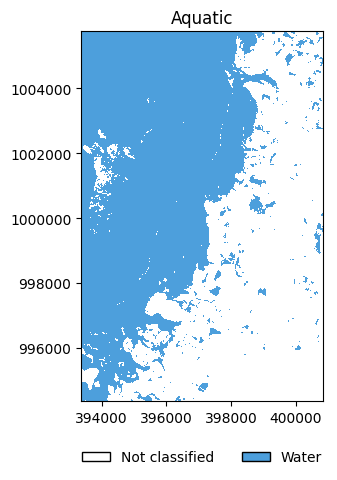

In [37]:
from colourschemes import water_colours, water_labels
#def plot_areas(input, colours, labels, title, output_file):
plot_areas(aquatic_wat_cat_ds.aquatic_wat_cat,water_colours, water_labels, title="Aquatic", output_file="../figures/aquatic_output.png")

### Method B
Aquatic covers are associated with inundated or tidal vegetation, with the latter including a) mangrove (GMW) and b) areas mapped as vegetated based on the fractional cover datasets that overlap with the tidal probablity layer of Murray et al. (2022).  

In [38]:
# Open Murray's tidal wetland probability (2017-2019) file as xarray
#TIDAL_WETLAND_S3 = '/home/jovyan/data/Tidal_wetland_Murray_20172019_30m_PNG.tif'
#tidal_wetland = rio_slurp_xarray(TIDAL_WETLAND_S3, gbox=vegetat_veg_cat_ds.geobox)

# Threshold probability layer to 50%
#tidal_wetland_extent = ((tidal_wetland.where(tidal_wetland > 50)) * 0 + 1).fillna(0)

# Remove mudflats from Murray's layer
#tidal_wetland_veg = vegetat_veg_cat_ds.vegetat_veg_cat * tidal_wetland_extent

# Create binary layer representing aquatic (1) and terrestrial (0)
# For coastal landscapes use the following
#aquatic_wat = wofs_mask + mangrove_2020 + tidal_wetland_veg
#aquatic_wat = (aquatic_wat.where(aquatic_wat > 0) * 0 + 1).fillna(0)

# Convert to dataset and add name
#aquatic_wat_cat_ds = aquatic_wat.to_dataset(name="aquatic_wat_cat")  # .squeeze().drop('time')

### 3. Natural Vegetation / Crop or Managed Vegetation

   * **Primarily Vegetated, Terrestrial, Artificial/Managed**: Cultivated and Managed Terrestrial Areas
   * **Primarily Vegetated, Terrestrial, (Semi-)natural**: Natural and Semi-Natural Vegetation
   * **Primarily Vegetated, Aquatic or Regularly Flooded, Artificial/Managed**: Cultivated Aquatic or Regularly Flooded Areas
   * **Primarily Vegetated, Aquatic or Regularly Flooded, (Semi-)natural**: Natural and Semi-Natural Aquatic or Regularly Flooded Vegetation


### Cultivated area from ESA World Cover

In [ ]:
#cultivated_2020 = ESA_WorldCover.classification == 40

In [ ]:
# Create binary layer representing vegetated (1) and non-vegetated (0)

# For coastal landscapes use the following
cultman_agr_cat = cultivated_2020

# Convert to Dataset and add name
cultman_agr_cat_ds = cultman_agr_cat.to_dataset(name="cultman_agr_cat").squeeze().drop('time')     

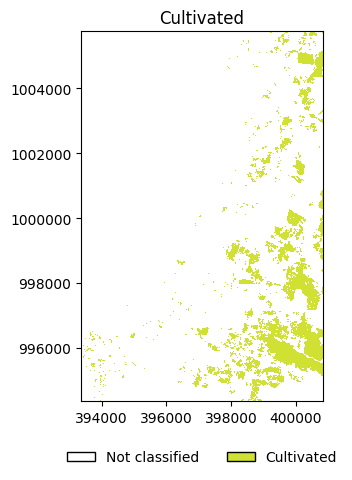

In [ ]:
from colourschemes import cultivated_colours, cultivated_labels
#def plot_areas(input, colours, labels, title, output_file):
plot_areas(cultman_agr_cat_ds.cultman_agr_cat, cultivated_colours, cultivated_labels, title="Cultivated", output_file="../figures/cultivated_output.png")

In [ ]:
# Need to add any tranformations for the VP you're using
# Get location of transformation
#transformation = "geomedian"
#trans_loc = importlib.import_module(transformation)
#trans_class = transformation.split('.')[-1]

#DEFAULT_RESOLVER.register('transform', trans_class, getattr(trans_loc, trans_class) )

# load geomedian
#product = catalog['geomedian']
#geomedian = product.load(dc, **query)

# Create binary layer representing cultivated (1) and natural (0)

# calculate NDVI (PLACEHOLDER)
#NDVI = (geomedian.nbart_nir-geomedian.nbart_red)/(geomedian.nbart_nir+geomedian.nbart_red)
#cultman = (NDVI >= 0.4) & (NDVI <= 0.7)

# Convert to Dataset and add name
#cultman_agr_cat_ds = cultman.to_dataset(name="cultman_agr_cat")#.squeeze().drop('time')

# Plot output
#cultman_agr_cat_ds["cultman_agr_cat"].plot.imshow(figsize=(6, 5))

In [ ]:
# load geomedian
#product = catalog['geomedian']
#geomedian = product.load(dc, **query)

In [ ]:
# Create binary layer representing cultivated (1) and natural (0)

# calculate NDVI (PLACEHOLDER)
#NDVI = (geomedian.nbart_nir-geomedian.nbart_red)/(geomedian.nbart_nir+geomedian.nbart_red)
#cultman = (NDVI >= 0.4) & (NDVI <= 0.7)

# Convert to Dataset and add name
#cultman_agr_cat_ds = cultman.to_dataset(name="cultman_agr_cat")#.squeeze().drop('time')

In [ ]:
# Plot output
#cultman_agr_cat_ds["cultman_agr_cat"].plot.imshow(figsize=(6, 5))

### 4. Natural Surfaces / Artificial Surfaces

In [ ]:
artificial_2020 = ESA_WorldCover.classification == 50

In [ ]:
# Create binary layer representing vegetated (1) and non-vegetated (0)

# For coastal landscapes use the following
artific_urb_cat = artificial_2020

# Convert to Dataset and add name
artific_urb_cat_ds = artific_urb_cat.to_dataset(name="artific_urb_cat").squeeze().drop('time')     

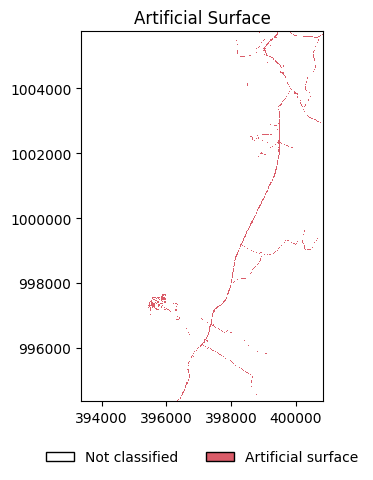

In [ ]:
from colourschemes import artsurf_colours, artsurf_labels
#def plot_areas(input, colours, labels, title, output_file):
plot_areas(artific_urb_cat_ds.artific_urb_cat, artsurf_colours, artsurf_labels, title="Artificial Surface", output_file="../figures/artsurf_output.png")

In [ ]:
# # load in OSM vector data just for AOI extent
# OSM_blds = gpd.read_file('/home/jovyan/livingearth_png/data/srilanka/srilanka_osm.gpkg', layer="gis_osm_buildings_a_free_1")
# #OSM_blds = gpd.read_file(OSM_S3, layer="buildings", bbox=bbox)
# #OSM_airports = gpd.read_file(OSM_S3, layer="aeroway_ln", bbox=bbox)
# #OSM_roads = gpd.read_file(OSM_S3, layer="highway_ln", bbox=bbox)

# # get bbox to get geom of gdf
# #xmin, ymin, xmax, ymax = bbox

# # Check if the vector dataset is empty
# if OSM_blds.empty:
#     # If the vector dataset is empty, create a raster of zeros matching the shape of the geomedians
#     OSM_blds_xr = xr.DataArray(
#         np.zeros_like(wofs_mask),
#         coords=wofs_mask.coords,
#         dims=wofs_mask.dims,
#         attrs=wofs_mask.attrs,
#     )
# else:
#     OSM_blds_AOI = OSM_blds.cx[xmin:xmax, ymin:ymax]
#     OSM_blds_xr = xr_rasterize(gdf=OSM_blds_AOI, da=wofs_mask)

# # Check if the vector dataset is empty
# if OSM_airports.empty:
#     # If the vector dataset is empty, create a raster of zeros matching the shape of the geomedians
#     OSM_airports_xr = xr.DataArray(
#         np.zeros_like(wofs_mask),
#         coords=wofs_mask.coords,
#         dims=wofs_mask.dims,
#         attrs=wofs_mask.attrs,
#     )
# else:
#     OSM_airports_AOI = OSM_airports.cx[xmin:xmax, ymin:ymax]
#     OSM_airports_xr = xr_rasterize(gdf=OSM_airports_AOI, da=wofs_mask)

#     # Check if the vector dataset is empty
# if OSM_roads.empty:
#     # If the vector dataset is empty, create a raster of zeros matching the shape of the geomedians
#     OSM_roads_xr = xr.DataArray(
#         np.zeros_like(wofs_mask),
#         coords=wofs_mask.coords,
#         dims=wofs_mask.dims,
#         attrs=wofs_mask.attrs,
#     )
# else:
#     # only selecting out roads that are sealed and fit the taxonomy of artificial surfaces
#     OSM_roads_filtered = OSM_roads[
#         OSM_roads["highway"].isin(
#             [
#                 "primary",
#                 "primary_link",
#                 "secondary",
#                 "secondary_link",
#                 "trunk",
#                 "trunk_link",
#             ]
#         )
#     ]
#     OSM_roads_AOI = OSM_roads.cx[xmin:xmax, ymin:ymax]
#     OSM_roads_xr = xr_rasterize(gdf=OSM_roads_AOI, da=wofs_mask)

# # combine OSM xarrays
# OSM_xr = xr.where(
#     (OSM_blds_xr == 1) | (OSM_airports_xr == 1) | (OSM_roads_xr == 1), 1, 0
# )

# # Convert to Dataset and add name
# artific_urb_cat_ds = OSM_xr.to_dataset(name="artific_urb_cat")


### **Collect environmental variables into array for passing to classification system**

In [ ]:
variables_xarray_list = []
variables_xarray_list.append(vegetat_veg_cat_ds)
variables_xarray_list.append(aquatic_wat_cat_ds)
variables_xarray_list.append(cultman_agr_cat_ds)
variables_xarray_list.append(artific_urb_cat_ds)
# variables_xarray_list.append(artwatr_wat_cat_ds)

## <font color=blue>Classification</font>

**The LCCS classificaition is hierachial. The 8 classes are shown below**

| Class name | Code | Numeric code |
|----------------------------------|-----|-----|
| Cultivated Terrestrial Vegetated | A11 | 111 |
| Natural Terrestrial Vegetated | A12 | 112 |
| Cultivated Aquatic Vegetated | A23 | 123 |
| Natural Aquatic Vegetated | A24 | 124 |
| Artificial Surface | B15 | 215 |
| Natural Surface | B16 | 216 |
| Artificial Water | B27 | 227 |
| Natural Water | B28 | 228 |


In [ ]:
# Merge to a single dataframe
classification_data = xr.merge(variables_xarray_list)

In [ ]:
# Apply Level 3 classification using separate function. Works through in three stages
level1, level2, level3 = lccs_l3.classify_lccs_level3(classification_data)

In [ ]:
# Save classification values back to xarray
out_class_xarray = xr.Dataset(
    {"level1" : (classification_data["vegetat_veg_cat"].dims, level1),
     "level2" : (classification_data["vegetat_veg_cat"].dims, level2),
     "level3" : (classification_data["vegetat_veg_cat"].dims, level3)})
classification_data = xr.merge([classification_data, out_class_xarray])

## <font color=blue>Results</font>

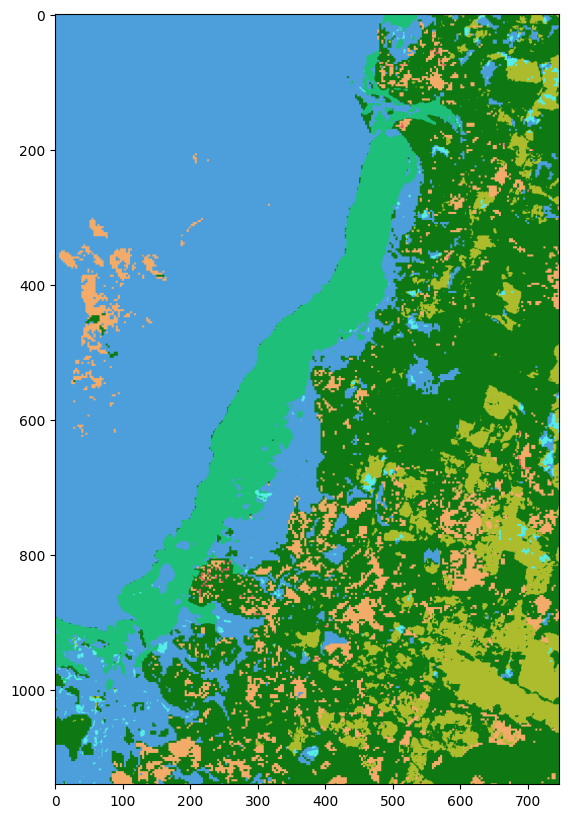

In [ ]:
red, green, blue, alpha = lccs_l3.colour_lccs_level3(level3)
img = np.dstack([red, green, blue, alpha])

# Rotate the image by 180 degrees - SHOULDN'T HAVE TO DO THIS BUT WAS NOT DISPLAYING PROPERLY
img = np.rot90(img, 2)

# Display the rotated image
plt.figure(figsize=(12, 10))
plt.imshow(img)
plt.show()


### **Save results to geotiff**

In [ ]:
min_x = classification_data.coords['x'].min().values
max_x = classification_data.coords['x'].max().values
min_y = classification_data.coords['y'].min().values
max_y = classification_data.coords['y'].max().values

res_x = 30 
res_y = -30 
crs = 'EPSG:32644'
# Write out
output_rgb_file_name = "../data/level3_test.tif"
out_file_transform = [res_x, 0, min_x, 0, res_y, max_y]
output_x_size = int((max_x - min_x)/res_x)
output_y_size = int((min_y - max_y)/res_y)

# Write RGB colour scheme out
rgb_dataset = rasterio.open(output_rgb_file_name, 'w', driver='GTiff',
                            height=output_y_size, width=output_x_size,
                            count=3, dtype=level3.dtype,
                            crs=crs, transform=out_file_transform)
rgb_dataset.write(red, 1)
rgb_dataset.write(green, 2)
rgb_dataset.write(blue, 3)
rgb_dataset.close()

In [ ]:
# Convert level3 to Dataset and add name
level3_ds = classification_data.level3.to_dataset(name="level3")

## <font color=blue>3. Constructing the FAO LCCS Level 4 classification</font>
The following generates Level 4 environmental descriptors, with focus on lifeform (woody and herbaceous) initially.

### 3. Lifeform
In the FAO LCCS, a lifeform category is defined which separates woody (trees and shrubs) from herbaceous (forbs, graminoids) categories.


| Category | Value| Components| 
|----------|:----------:|:----------:|
| Not applicable  | 0  | (e.g., water)  |
| Woody   | 1   | Trees and shrubs   |
| Herbaceous  | 2  | Forbs and graminoids   |

Two methods are currently available to map the extent of woody vegetation, with the remaining vegetation assumed to be herbaceous.   The first utilises the Woody Cover Fraction (WCF) derived from Landsat sensor data whilst the second is based on time-series of Sentinel-1 SAR data.   

In [ ]:
woody_2020 = (ESA_WorldCover.classification == 10) | (ESA_WorldCover.classification == 20)

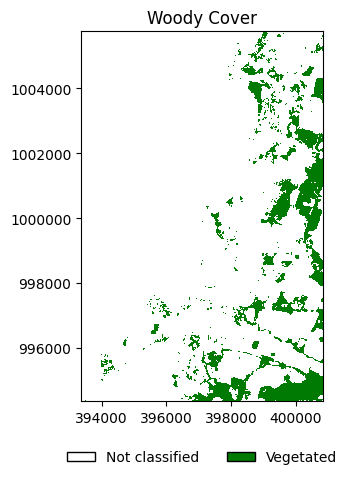

In [ ]:
plot_areas(woody_2020,vegetated_colours, vegetated_labels, title="Woody Cover", output_file="../figures/woody_output.png")

In [ ]:
lifeform = woody_2020
lifeform = lifeform.fillna(0)
lifeform_veg_cat_ds = lifeform.to_dataset(name="lifeform_veg_cat").squeeze()

In [ ]:
variables_xarray_list = []
variables_xarray_list.append(level3_ds)
# variables_xarray_list.append(waterstt_wat_cat_ds)
# variables_xarray_list.append(waterper_wat_cin_ds)
variables_xarray_list.append(lifeform_veg_cat_ds)
# variables_xarray_list.append(canopyco_veg_con_ds)

In [ ]:
# Merge to a single dataframe
l4_classification_data = xr.merge(variables_xarray_list)

In [ ]:
# Apply Level 4 classification
classification_array = lccs_l4.classify_lccs_level4(l4_classification_data)

In [ ]:
# Get Level 4 codes to apply colour scheme
l4_classification_codes = lccs_l4.get_lccs_level4_code(classification_array)
print(np.unique(l4_classification_codes))

['A11' 'A12' 'A12.A1' 'A23' 'A24' 'B15' 'B16' 'B20']


In [ ]:
classification_level4 = (classification_array.level3*10.)+(
                       classification_array.lifeform_veg_cat_l4a)
print(np.unique(classification_level4))

[1110. 1120. 1121. 1230. 1240. 2150. 2160. 2200.]


## <font color=blue>Level 4 results</font>

In [ ]:
# red, green, blue, alpha = lccs_l4.colour_lccs_level4(level4)
# img = np.dstack([red, green, blue, alpha])

# # Rotate the image by 180 degrees - SHOULDN'T HAVE TO DO THIS BUT WAS NOT DISPLAYING PROPERLY
# img = np.rot90(img, 4)

# # Display the rotated image
# plt.figure(figsize=(12, 10))
# plt.imshow(img)
# plt.show()


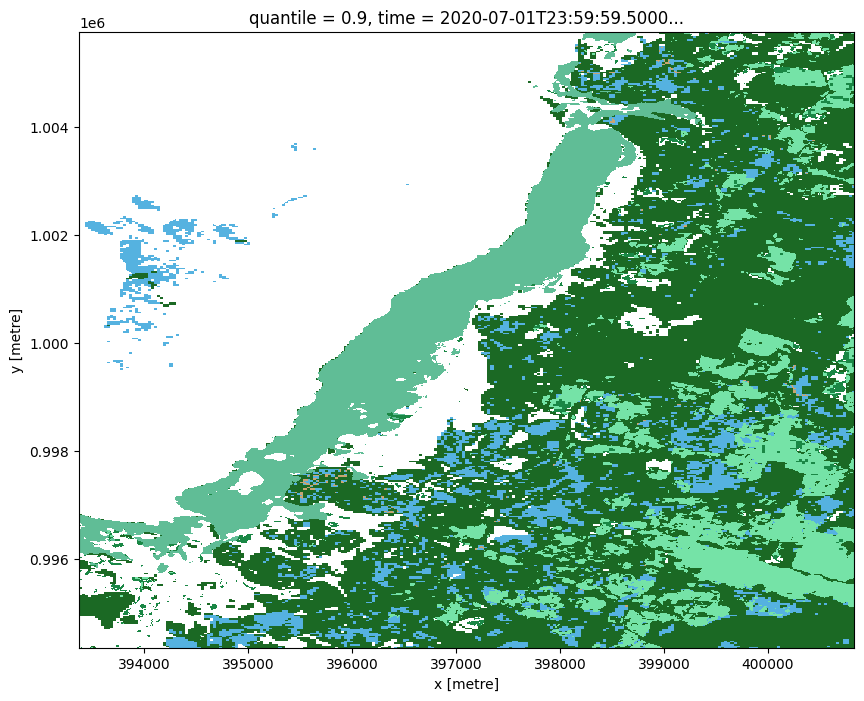

In [ ]:
from matplotlib.colors import ListedColormap

# create a custom colormap with green, yellow, and brown colors
cmap = ListedColormap(["#ffffff", "#AFBC49", "#377726", "#75e3a7", "#1b6924", "#88e673",
                       "#1a8745", "#60bd96", "#b1a9ba", "#e65a5a", "#c9a571", "#55b2e0"])

# specify the color levels corresponding to each value
levels = [0., 1110, 1120, 2.5, 3.5, 1121.5, 1122.5, 
          1240, 1242.5, 2000.5, 2150, 2160, 2200]

# create the plot with custom colors and color levels
# plot = BCE.plot(cmap=cmap, levels=levels, add_colorbar=False)
plot = classification_level4.plot(cmap=cmap, levels=levels, add_colorbar=False)

# add a legend
# legend_labels = {1: "Mangrove", 2: "Tidal woody", 3: "Saltmarsh"}
# handles = [plt.Rectangle((0,0),1,1, color=color) for color in cmap(np.arange(cmap.N))]
# labels = [legend_labels[i+1] for i in range(len(legend_labels))]
# plt.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left')

# change fig size and show the plot
fig = plt.gcf()
fig.set_size_inches(10, 8)
plt.savefig("../figures/level4.png", dpi=300, bbox_inches="tight")
plt.show()

## <font color=blue>4. Underwater classification</font>
The following generates or accesses maps of underwater habitats, including seagrasses and coral distributions.

### 4.1 Seagrass extent
In this notebook, the Submerged Seagrasses Identification Index (SSI), which is based on spectral features from Sentinel-2 bands such as the red edge and visible bands, is used. Non-submerged seagrasses are identified using the Normalized Difference vegetation Index (NDVI). For the specified area of interest and time periods for data extraction, true color composites (which allow visualisation of the seagrass areas) and maps of SSII are generated, with the latter allowing submerged seagrasses to be distinguished from other vegetation and water bodies with binary maps generated by thresholding the index.  The maps can be generated from cloud-free Sentinel-2 imagery available for a study area and you can select and change the time-period as required.  A second approach based on machine learning (ML: Sorkhabi et al., 2024) uses a time-series of Sentinel-2 data rather than single-date imagery. 

Li, Y., Bai, J., Chen, S., Chen, B., & Zhang, L. (2023). Mapping seagrasses on the basis of Sentinel-2 images under tidal change. Marine Environmental Research, 185, 105880.
Seagrass Flowchart
  

Data time: 2020-10-27T05:16:14.134000000
SSII map saved as SSII_2020-10-27_80.03_80.0975_9.0973_8.9945.tif


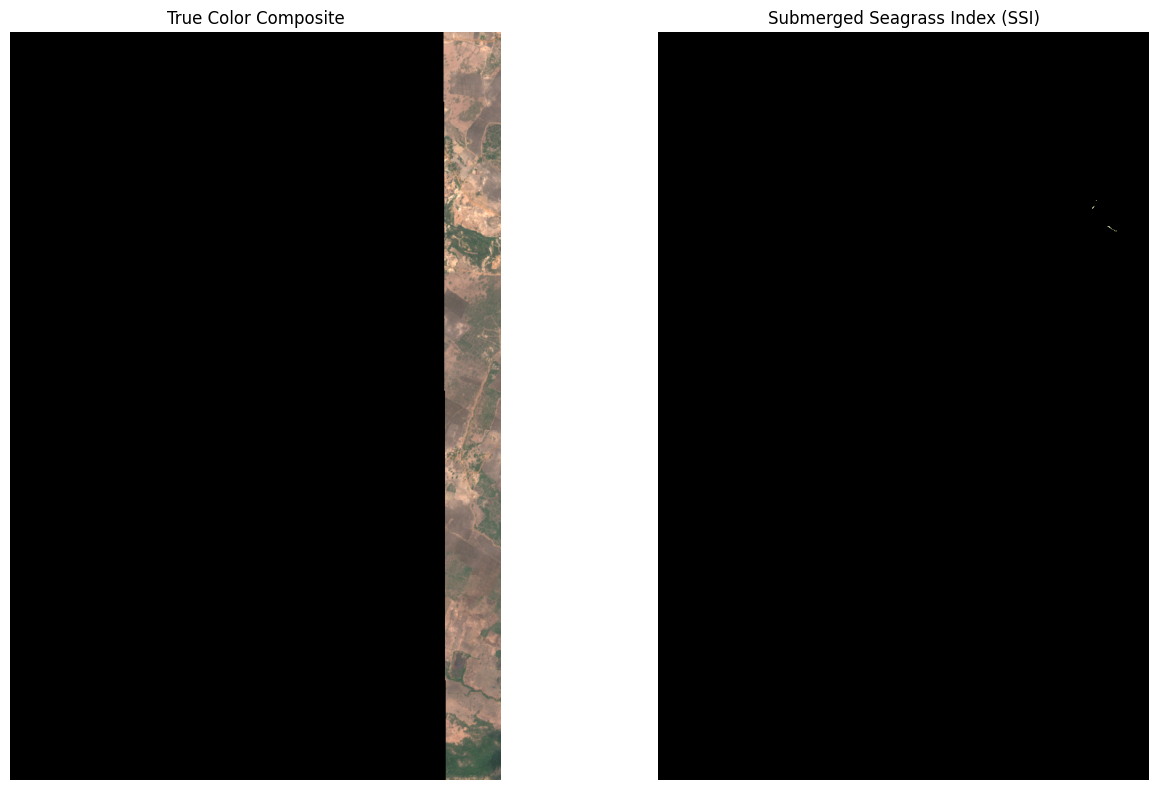

In [69]:
time_range = (datetime.datetime(2020, 10, 26), datetime.datetime(2020, 10, 30))
display_map(longitude,latitude)
plot_s2_true_color_and_ssii(longitude, latitude, time_range)

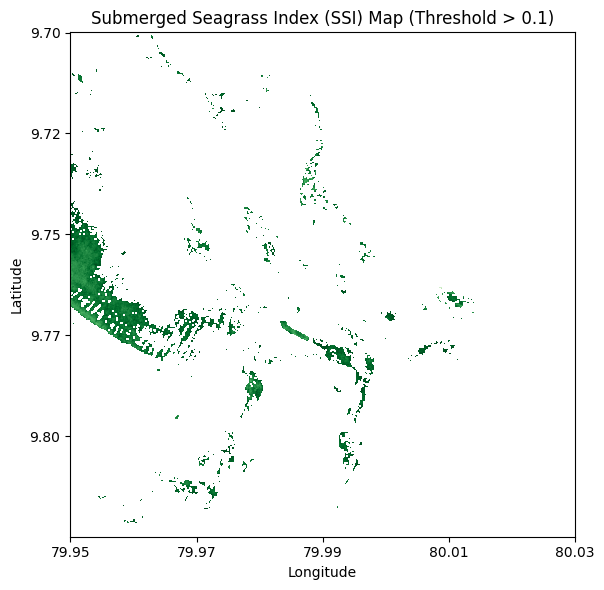

In [70]:
# #plot Saved Tiff with threshold
tif_file = "SSII_2024-08-12_79.95_80.03_9.6_9.7.tif"  # Path to your saved SSII TIFF file
plot_saved_ssii_tif(tif_file, threshold=0.1)

In [72]:
seagrass = "/home/jovyan/livingearth_png/notebooks/SSII_2024-08-14_81.7659_81.8382_7.4777_7.4023.tif"

In [73]:
from datacube.utils.geometry import GeoBox, CRS, Geometry
import numpy as np

# Define time range (if needed, otherwise omit)
time = ('2020-10-01', '2020-12-31')  # Example time range, adjust as needed

# Set CRS and resolution
crs = CRS("EPSG:32644")  # For Sri Lanka (adjust for your use case)
res = (10, -10)  # Pixel resolution

# # # # East Sri Lanka
# latitude = (9.1051, 8.9045)
# longitude = (79.8350, 80.0975)


# Define spatial extent (latitude and longitude bounds)
latitude = (9.1051, 8.9045)  # (max_lat, min_lat)
longitude = (79.8350, 80.0975)  # (min_lon, max_lon)

# Create a Geometry bounding box using the latitude and longitude
bbox = Geometry(
    {
        "type": "Polygon",
        "coordinates": [[
            [longitude[0], latitude[0]],  # Bottom-left
            [longitude[1], latitude[0]],  # Bottom-right
            [longitude[1], latitude[1]],  # Top-right
            [longitude[0], latitude[1]],  # Top-left
            [longitude[0], latitude[0]],  # Closing the polygon
        ]]
    },
    crs=crs
)

# Create GeoBox
geobox = GeoBox.from_geopolygon(bbox, resolution=res)

print("GeoBox created: ", geobox)

GeoBox created:  GeoBox(Geometry({'type': 'Polygon', 'coordinates': (((76.51206242576244, 0.0), (76.5120624257569, 9.019385840374443e-05), (76.51197283569599, 9.01938472590706e-05), (76.51197283570151, 0.0), (76.51206242576244, 0.0)),)}, CRS('EPSG:4326')))


In [74]:
display_map(longitude, latitude)

In [75]:
seagrass_prj = rio_slurp_xarray(seagrass,
                                      geobox,
                                      resampling="nearest")

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "rasterio/_base.pyx", line 308, in rasterio._base.DatasetBase.__init__
  File "rasterio/_base.pyx", line 219, in rasterio._base.open_dataset
  File "rasterio/_err.pyx", line 221, in rasterio._err.exc_wrap_pointer
rasterio._err.CPLE_OpenFailedError: /home/jovyan/livingearth_png/notebooks/SSII_2024-08-14_81.7659_81.8382_7.4777_7.4023.tif: No such file or directory

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/env/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3460, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_120/7376411.py", line 1, in <module>
    seagrass_prj = rio_slurp_xarray(seagrass,
  File "/env/lib/python3.10/site-packages/datacube/testutils/io.py", line 388, in rio_slurp_xarray
    im, mm = rio_slurp_reproject(fname, *args, **kw)
  File "/env/lib/python3.10/site-packages/datacube/testutils/io.py", line 29

In [ ]:
# seagrass_prj

In [76]:
seagrass_2020 = []
seagrass_2020 = (seagrass_prj.where(seagrass_prj > 0.2)) * 204

NameError: name 'seagrass_prj' is not defined

In [77]:
seagrass_2020.values

AttributeError: 'list' object has no attribute 'values'

In [78]:
plt(seagrass_2020)

TypeError: 'module' object is not callable

In [79]:
variables_xarray_list = []
variables_xarray_list.append(level3_ds)
variables_xarray_list.append(seagrass_2020)

In [80]:
named_variables = []
for i, da in enumerate(variables_xarray_list):
    if da.name is None:
        da = da.rename(f"var_{i}")  
    named_variables.append(da)

underwater_data = xr.merge(named_variables)

AttributeError: 'Dataset' object has no attribute 'name'

In [81]:
variables_xarray_list

[<xarray.Dataset>
 Dimensions:      (y: 1140, x: 746)
 Coordinates:
   * y            (y) float64 9.944e+05 9.944e+05 ... 1.006e+06 1.006e+06
   * x            (x) float64 4.008e+05 4.008e+05 ... 3.934e+05 3.934e+05
     spatial_ref  int32 32644
     quantile     float64 0.9
 Data variables:
     level3       (y, x) uint8 112 112 112 112 112 112 ... 220 220 220 220 220,
 []]

In [82]:
# # Merge to a single dataframe
underwater_data = xr.merge(variables_xarray_list)

TypeError: objects must be an iterable containing only Dataset(s), DataArray(s), and dictionaries.

## 4. Blue Carbon Ecosystems

In [83]:
# combine
BCE = gmw_2020 + saltmarsh_2020# + tidal_woody_class
BCE = BCE.where(BCE !=0, classification_level4)

In [2]:
from matplotlib.colors import ListedColormap

# create a custom colormap with green, yellow, and brown colors
cmap = ListedColormap(["#ffffff", "#AFBC49", "#377726", "#CBF226", "#487526", "#83E9E6",
                       "#5ABC7F", "#6ACDB4", "#CB646B", "#BFF0D7", "#E8AE74", "#2B53B3"])

# "#ffffff": No data
# "#AFBC49": 111 CTV
# "#377726": 112 NTV
# "#CBF226": 1121 NVT woody
# "#487526": 1122 NTV herbaceous
# "#83E9E6": 123 CAV
# "#5ABC7F": 124 NAV
# "#6ACDB4": 1241 NVT woody
# "#BFF0D7": 1242 NTV herbaceous
# "#CB646B": 215 AS
# "#E8AE74": 216 BS
# "#2B53B3": 220 WATER


# specify the color levels corresponding to each value
levels = [0., 111, 112, 1121.5, 1122.5, 1241.5, 1242.5, 2000.5, 2150.5, 2160.5, 2200.5]

# create the plot with custom colors and color levels
# plot = BCE.plot(cmap=cmap, levels=levels, add_colorbar=False)
plot = BCE.plot(cmap=cmap, levels=levels, add_colorbar=False)

# add a legend
# legend_labels = {1: "Mangrove", 2: "Tidal woody", 3: "Saltmarsh"}
# handles = [plt.Rectangle((0,0),1,1, color=color) for color in cmap(np.arange(cmap.N))]
# labels = [legend_labels[i+1] for i in range(len(legend_labels))]
# plt.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left')

# change fig size and show the plot
fig = plt.gcf()
fig.set_size_inches(10, 8)
plt.savefig("../figures/bce.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'BCE' is not defined

### **Save results to geotiff**

In [ ]:
min_x = classification_data.coords['x'].min().values
max_x = classification_data.coords['x'].max().values
min_y = classification_data.coords['y'].min().values
max_y = classification_data.coords['y'].max().values

res_x = 30 
res_y = -30 
crs = 'EPSG:32644'
# Write out
output_rgb_file_name = "../data/level4_test.tif"
out_file_transform = [res_x, 0, min_x, 0, res_y, max_y]
output_x_size = int((max_x - min_x)/res_x)
output_y_size = int((min_y - max_y)/res_y)

# Write RGB colour scheme out
rgb_dataset = rasterio.open(output_rgb_file_name, 'w', driver='GTiff',
                            height=output_y_size, width=output_x_size,
                            count=3, dtype=BCE.dtype,
                            crs=crs, transform=out_file_transform)
rgb_dataset.write(red, 1)
rgb_dataset.write(green, 2)
rgb_dataset.write(blue, 3)
rgb_dataset.close()

In [ ]:
BCE

## <font color=blue>5. Estimating BCE carbon amounts for areas in Southeast Asia</font>
The following generates estimates of carbon in the above and below ground components of woody and herbaceous terrestrial/aquatic vegetation as well as intertidal seagrasses. 

### 3.1 Woody vegetation
#### 3.1.1 Above ground biomass

The above ground biomass (AGB) for woody vegetation was determined from the European Space Agency's (ESA) Climate Change Initiative (CCI) Biomass project.  AGB was retreived using time-series of ESA's C-band data and the Japan Aerospace Exploration Agency's (JAXA) L-band Synthetic Aperture Radar (SAR) data.

| Carbon Store | Units | Conversion Factor| Reference |
|----------|:---------------------------:|:----------:|----------|
| All woody  (Mangroves and SCFF)  | Mg/ha   | 1   | Santoro et al. (2024)  |

#### Loading ESA CCI AGB data
Load the selected above ground biomass data (estimate plus standard deviation of the estimate)for the area and year of interest (in this case, 2020).

In [86]:
from datacube.testutils.io import rio_slurp_xarray

# Path to the AGB2020 raster file
AGB2020 = "/home/jovyan/livingearth_png/data/srilanka/AGB/N10E70/N10E70_AGB_cz.tif"

# Use rio_slurp_xarray to load the raster
AGB2020_prj = rio_slurp_xarray(AGB2020,
                                geobox,
                                resampling="nearest")

# Print the loaded data
print(AGB2020_prj)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "rasterio/_base.pyx", line 308, in rasterio._base.DatasetBase.__init__
  File "rasterio/_base.pyx", line 219, in rasterio._base.open_dataset
  File "rasterio/_err.pyx", line 221, in rasterio._err.exc_wrap_pointer
rasterio._err.CPLE_OpenFailedError: /home/jovyan/livingearth_png/data/srilanka/AGB/N10E70/N10E70_AGB_cz.tif: No such file or directory

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/env/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3460, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_120/3109966661.py", line 7, in <module>
    AGB2020_prj = rio_slurp_xarray(AGB2020,
  File "/env/lib/python3.10/site-packages/datacube/testutils/io.py", line 388, in rio_slurp_xarray
    im, mm = rio_slurp_reproject(fname, *args, **kw)
  File "/env/lib/python3.10/site-packages/datacube/testutils/io.py", line 292, in rio_slurp_

In [ ]:
import rasterio

with rasterio.open(filepath) as src:
    print(src.crs)  # Check coordinate system
    print(src.transform)  # Check geotransform

In [ ]:
import rasterio

filepath = "N10E70_80_AGB_cz_UTM44_10m.tif"

with rasterio.open(filepath) as src:
    small_window = src.read(1, window=((0, 5000), (0, 5000)))  #

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming AGB2020_SD_prj is the data loaded using rio_slurp_xarray
# If the result is an xarray.DataArray, you can extract the array using .values
agb_data = AGB2020.values

# Plotting with matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(agb_data, cmap='terrain', interpolation='nearest')

# Add colorbar to represent the scale of the data
plt.colorbar(label="AGB 2020 (SD)")

# Add a title to the plot
plt.title("AGB2020 (Terrain Colors)")

# Add labels and adjust axes
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

In [ ]:
import rasterio
from datacube.utils.geometry import GeoBox, CRS
from datacube.utils import geometry

# Define CRS and resolution
crs_target = CRS("EPSG:32644")  
res = (10, -10)

# Define bounding box in LAT/LON
lat_range = (7.4777, 7.4023)
lon_range = (81.7659, 81.8382)

# Create geopolygon in EPSG:4326 and reproject to EPSG:32645
bounding_polygon = geometry.box(lon_range[0], lat_range[0], lon_range[1], lat_range[1], CRS("EPSG:4326"))
bounding_polygon_utm = bounding_polygon.to_crs(crs_target)

# Create GeoBox
geobox = GeoBox.from_geopolygon(bounding_polygon_utm, resolution=res)

# Load raster
AGB2020_prj = rio_slurp_xarray(AGB2020, geobox, resampling="bilinear")

# Manually assign CRS if missing
if "crs" not in AGB2020_prj.attrs:
    with rasterio.open(AGB2020) as src:
        AGB2020_prj.attrs["crs"] = src.crs

# Verify output
print("Dataset CRS:", AGB2020_prj.attrs["crs"])
print("Dataset Shape:", AGB2020_prj.shape)

In [ ]:
from datacube.utils.geometry import GeoBox, CRS

print("GeoBox CRS:", geobox.crs)
print("GeoBox Bounds:", geobox.extent.boundingbox)

In [ ]:
from datacube.utils.geometry import GeoBox
import rasterio

# Define a valid GeoBox (Ensure latitude & longitude are set correctly)
geobox = geobox

# Read the raster file
AGB2020_prj = rio_slurp_xarray(AGB2020, geobox, resampling="nearest")

print(AGB2020_prj)

In [87]:
AGB2020_SD = "/home/jovyan/livingearth_png/data/srilanka/AGB/N10E70/N10E70_2020_SD_cz.tif"

In [88]:
AGB2020_SD_prj = rio_slurp_xarray(AGB2020_SD,
                                      geobox,
                                      resampling="nearest")

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "rasterio/_base.pyx", line 308, in rasterio._base.DatasetBase.__init__
  File "rasterio/_base.pyx", line 219, in rasterio._base.open_dataset
  File "rasterio/_err.pyx", line 221, in rasterio._err.exc_wrap_pointer
rasterio._err.CPLE_OpenFailedError: /home/jovyan/livingearth_png/data/srilanka/AGB/N10E70/N10E70_2020_SD_cz.tif: No such file or directory

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/env/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3460, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_120/2827456507.py", line 1, in <module>
    AGB2020_SD_prj = rio_slurp_xarray(AGB2020_SD,
  File "/env/lib/python3.10/site-packages/datacube/testutils/io.py", line 388, in rio_slurp_xarray
    im, mm = rio_slurp_reproject(fname, *args, **kw)
  File "/env/lib/python3.10/site-packages/datacube/testutils/io.py", line 292, in 

In [89]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming AGB2020_SD_prj is the data loaded using rio_slurp_xarray
# If the result is an xarray.DataArray, you can extract the array using .values
agb_data = AGB2020_prj.values

# Plotting with matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(agb_data, cmap='terrain', interpolation='nearest')

# Add colorbar to represent the scale of the data
plt.colorbar(label="AGB 2020 (SD)")

# Add a title to the plot
plt.title("AGB2020 (Terrain Colors)")

# Add labels and adjust axes
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

NameError: name 'AGB2020_prj' is not defined

In [ ]:
import matplotlib.pyplot as plt

# Plot the raster
plt.figure(figsize=(10, 6))  # Adjust figure size
AGB2020_prj.plot(cmap="terrain", vmin = 5, vmax = 400, add_labels=False)  # Use a colormap (e.g., viridis, plasma, gray)

# Add title and labels
plt.title("Above Ground Biomass (Mg ha-1) for 2020")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

#### 3.1.2 Below ground biomass
The below ground biomass (BGB) for woody vegetation is a proportion (0.2) based on estimates from Author et al. (0000).

| Carbon Store | Units | Conversion Factor| Reference |
|----------|:----------:|:----------:|----------|
| Mangroves   | Mg/ha   | 0.49   | Author   |
| SCFF  | Mg/ha   | 0.49   | Author   |


In [ ]:
BGB2020_prj = AGB2020_prj * 0.49

In [ ]:
# Plot the raster
plt.figure(figsize=(10, 6))  # Adjust figure size
BGB2020_prj.plot(cmap="terrain", vmin = 5, vmax = 200, add_labels=False)  # Use a colormap (e.g., viridis, plasma, gray)

# Add title and labels
plt.title("Mangrove Below Ground Biomass (BGB)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

### 3.2. Herbaceous vegetation
#### 3.2.1 Above ground biomass
For tidal marshes and seagrass respectively, the above ground biomass was estimated from Strydom et al. (2023) and Collier et al. (2021).

| Carbon Store | Units | Conversion Factor| Reference |
|----------|:----------:|:----------:|----------|
|Seagrass  | Mg/ha  | 3.65 | Strydom (2023) |
|Tidal marshes  | Mg/ha  | 3.65 | Collier et al. (2021) |


In [ ]:
#seagrass_2020*3.65 

#### 3.2.2 Below ground biomass

Estimated from recommended equations in the IPCC Wetlands supplement (IPCC 2014) and from Howard et al. (2014) and both Strydom et al. (2023) and Collier et al. (2021)). These estimates were taken from a synthesis of studies undertaken at the global (e.g., IPCC), realm (e.g., for Indo-Pacific/Oceania) and regional (mainly Papua and West Papua, Indonesia), including those reporting conversion factors between the above and below ground components.

| Blue Carbon Ecosystem | Units | Conversion Factor| Reference |
|----------|:----------:|:----------:|----------|
| Tidal marshes  | Mg/ha  | 3.65 | IPCC (2014); Howard et al. (2014),Strydom et al. (2023), Collier et al. 2021)  |


### 3.3 Soil organic carbon
Conservatively estimated using average amounts for the Indo-Pacific region summarised for mangroves ((Sanderman et al. 2018); (Kauffman et al. 2020)), tidal peatlands (indicative of SCFF; (Taberima et al. 2018)), tidal marshes ((Taberima et al. 2018)) and seagrass ((Kennedy et al. 2022; Stankovic et al. 2021)).


| Blue Carbon Ecosystem | Units | Amount| Reference |
|----------|:----------:|:----------:|----------|
| Mangroves  | Mg/ha  | 0.00 | Sanderman et al. (2018) |
| Tidal peatlands (indicative of SCFF)  | Mg/ha  | 0.00| Taberima et al. (2018) |
| Tidal marshes  | Mg/ha  | 0.00 | Taberima et al. (2018) |
| Seagrass  | Mg/ha  | 0.00 | Kennedy et al. (2022); Stankovic et al. (2021)|







Hengl et al. (2020) provides global soil organic carbon stocks in mangrove forests at 30 m resolution, with these predicted for 2020 using spatiotemporal ensemble machine learning. Soil organic carbon stock (t/ha) has been derived using predictions of soil organic carbon content and bulk density (BD) to 1 m soil depth, which were then aggregated to calculate soil organic carbon stocks.

The "mangroves_tiles_SOC_predictions_2020.zip" file contains predictions of SOC content, Bulk Density (BD) and aggregated SOC stocks (t/ha) for 0—100 cm depth interval.  The layer used is: 


**Predicted SOC stocks in t/ha (mean value):** sol_soc.tha_mangroves.typology_m_30m_s0..100cm_2020_global_v0.1.tif = ;

Other layers that can be integrated are:

**Predicted BD aggregated to 0—100 cm:**
sol_db.od_mangroves.typology_m_30m_s0..100cm_2020_global_v0.1.tif

**predicted SOC content (%) at 0 cm depth (surface soil):** sol_soc.wpct_mangroves.typology_m_30m_s0..0cm_2020_global_v1.1.tif

**predicted SOC content (%) for 0—100 cm:**
sol_soc.wpct_mangroves.typology_m_30m_s0..100cm_2020_global_v1.1.tif = 

**predicted SOC stocks in t/ha lower 95% probability prediction interval:** sol_soc.tha_mangroves.typology_l.std_30m_s0..100cm_2020_global_v0.1.tif = ;

**predicted SOC stocks in t/ha upper 95% probability prediction interval** sol_soc.tha_mangroves.typology_u.std_30m_s0..100cm_2020_global_v0.1.tif = 

#### Soil Organic Carbon for mangroves

In [ ]:
from datacube.testutils.io import rio_slurp_xarray

# Path to the AGB2020 raster file
SOC2020_M = "/home/jovyan/livingearth_png/data/srilanka/SOC/SOC_2020_SriLanka_Mean.tif"

# Use rio_slurp_xarray to load the raster
SOC2020_M_prj = rio_slurp_xarray(SOC2020_M,
                                geobox,
                                resampling="nearest")

# Path to the AGB2020 raster file
SOC2020_SDL = "/home/jovyan/livingearth_png/data/srilanka/SOC/SOC_2020_SriLanka_Mean.tif"

# Use rio_slurp_xarray to load the raster
SOC2020_SDL_prj = rio_slurp_xarray(SOC2020_SDL,
                                geobox,
                                resampling="nearest")

# Path to the AGB2020 raster file
SOC2020_SDU = "/home/jovyan/livingearth_png/data/srilanka/SOC/SOC_2020_SriLanka_Mean.tif"

# Use rio_slurp_xarray to load the raster
SOC2020_SDU_prj = rio_slurp_xarray(SOC2020_SDU,
                                geobox,
                                resampling="nearest")


# Print the loaded data
print(SOC2020_M_prj)
print(SOC2020_SDL_prj)
print(SOC2020_SDU_prj)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming AGB2020_SD_prj is the data loaded using rio_slurp_xarray
# If the result is an xarray.DataArray, you can extract the array using .values
SOCm_data = SOC2020_M_prj.values

# Plotting with matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(SOCm_data, cmap='terrain', interpolation='nearest')

# Add colorbar to represent the scale of the data
plt.colorbar(label="Mean Soil Organic Carbon (Mg/ha)")

# Add a title to the plot
plt.title("Mean Soil Organic Carbon (Mangroves)")

# Add labels and adjust axes
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()


#### Soil Organic Carbon for tidal peatlands (indicative of SCFF)

#### Soil Organic Carbon for tidal marshes

#### Soil Organic Carbon for seagrass